# Exploratory Data Analysis in R

In this workshop we will cover Exploratory Data Analysis (EDA) in R.

## Learning Outcomes

By the end of this workshop, you will be able to

- Load data into a dataframe
- Assess general characteristics of your data (e.g. data types, column names)
- Generate descriptive statistics
- Quantify missingness and outliers
- Visualize univariate, bivariate and multivariate data.
- Identify potential relationships of interest which could be explored using modeling



We will use a dataset which has been handed to us by Barbara who works at NC State University. She has asked us to determine the following:

1. What columns are in the data and what are their values?
2. Are there any problems with the data? Outliers? Missing Values? Data type issues?
3. What variance to you see in the individual values?
4. What is the covariance between variables in the dataset?
5. Does covariance between any variables lead to an interesting model?

Barbara would like reporting and visualization of the data. We have no additional information about the data except a post-it note that was left on our desk.

![post-it note](https://github.com/NCSU-Libraries/intro-to-prog-r/blob/main/assets/notebooks/post_it_note_small.png?raw=true)

### Load Packages


In [1]:
# If tidyverse isn't installed, install it
if (!require(tidyverse)) {
    install.packages("tidyverse")
}

# load tidyverse
library(tidyverse)

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Load Data

In [2]:
# Create variable to hold url to raw data in github
mascot.url <- "https://raw.githubusercontent.com/NCSU-Libraries/eda-with-r/refs/heads/main/data/NCSU_Mascots_v1.csv"
celeb.url <- "https://raw.githubusercontent.com/NCSU-Libraries/eda-with-r/refs/heads/main/data/NCSU%20Celebrity%20Graduates_v1.csv"

# read in data
mascot.data <- read.csv(mascot.url)

# Look at first few rows of data
head(mascot.data)

,Name,Species,Breed,Prior.Position,Prior.Employer,Interview.Date,Hire.Year,Hire.Date,Termination.Year,Termination.Date,⋯,Nick.Name,Temperment,Fur.Color,Age,Height,Weight,Offer.Sent,Starting.Salary,Biter,Hired
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>
1,Wallace Whitfield Riddick,Human,,,,1899-02-17,1899,1899-02-23,NA,,⋯,,patient,cream,5.0,34.5,40.0,1,9481,0,1
2,Tige,Dog,English Bulldog,,,1910-02-16,1910,1910-02-17,NA,,⋯,,sweet,brown,10.9,14.2,51.0,1,10130,0,1
3,Togo,Dog,American Bulldog,,,1910-06-28,1910,1910-07-01,NA,,⋯,,sweet,brown,10.4,24.4,90.0,1,9572,0,1
4,State,Wolf,Timber Wolf,,,1940-05-02,1940,1940-05-03,1946,1940-05-17,⋯,,bewildered,multi-color,9.8,29.8,112.5,1,9921,0,1
5,Lobo I,Wolf,Timber Wolf,Zoo,Philadelphia Zoo,1959-08-26,1959,1959-09-03,1959,1959-05-29,⋯,,quiet,gray,10.3,27.2,100.15,1,9509,0,1
6,Lobo II,Wolf,Timber Wolf,,,1960-02-17,1960,1960-02-23,NA,,⋯,,devilishly clever,multi-color,7.4,31.0,120.73,1,10424,0,1


In [3]:
# look at the last few rows
tail(mascot.data, 4) # we can set the number of rows shown

,Name,Species,Breed,Prior.Position,Prior.Employer,Interview.Date,Hire.Year,Hire.Date,Termination.Year,Termination.Date,⋯,Nick.Name,Temperment,Fur.Color,Age,Height,Weight,Offer.Sent,Starting.Salary,Biter,Hired
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<int>,<int>,<int>,<int>
47,Clover,Rabbit,Mini Rex,Burrow Engineer,Hillside Civil Engineering,1952-07-30,NA,,NA,,⋯,,frightened,brown,10.0,12.40,3.71,0,NA,0,0
48,Sophie,Rabbit,Holland Lop,Carrot Quality Control Associate,Publix,1953-11-17,NA,,NA,,⋯,Spock,social,black,9.7,10.55,3.18,1,9904,0,0
49,Pixel,Turtle,Eastern Box,Rock Impersonator,"No Moves, LLC",1997-08-25,NA,,NA,,⋯,Gizmo,patient,,11.6,5.44,1.49,0,NA,0,0
50,Baron,Dog,Dalmatian,Firehouse Morale Officer,Raleigh Fire Department,1990-08-06,NA,,NA,,⋯,,social,black,14.7,21.50,57.68,0,NA,0,0


### Summarize Data Shape & Type

We can use [`glimpse()`](https://www.rdocumentation.org/packages/pillar/versions/1.6.2/topics/glimpse) to get the shape of our data (# of rows and columns), column names, data types and first few values for each column.

In [4]:
glimpse(mascot.data)

Rows: 50
Columns: 22
$ Name                     <chr> "Wallace Whitfield Riddick", "Tige", "Togo", …
$ Species                  <chr> "Human", "Dog", "Dog", "Wolf", "Wolf", "Wolf"…
$ Breed                    <chr> "", "English Bulldog", "American Bulldog", "T…
$ Prior.Position           <chr> "", "", "", "", "Zoo", "", "", "Pet", "", "Ch…
$ Prior.Employer           <chr> "", "", "", "", "Philadelphia Zoo", "", "", "…
$ Interview.Date           <chr> "1899-02-17", "1910-02-16", "1910-06-28", "19…
$ Hire.Year                <int> 1899, 1910, 1910, 1940, 1959, 1960, 1966, 197…
$ Hire.Date                <chr> "1899-02-23", "1910-02-17", "1910-07-01", "19…
$ Termination.Year         <dbl> NA, NA, NA, 1946, 1959, NA, 1970, NA, NA, NA,…
$ Termination.Date         <chr> "", "", "", "1940-05-17", "1959-05-29", "", "…
$ Termination.Reason       <chr> "", "", "", "New Job", "Passed Away", "Escape…
$ Post.Employment.Position <chr> "", "", "", "Traveling Zoo", "", "Art Thief",…
$ Nick.Name        

Initial observations of the data include:

- We have 50 observations (rows)
- We have 22 variables (cols) for each observation
- Some variables seem to be missing values.

We initially categorize our variables into two broad data types:

<table>
<tr>
<th> Numeric </th>
<th> Character </th>
</tr>
<tr>
<td>

- Hire.Year
- Termination.Year
- Age
- Height
- Offer.Sent
- Starting.Salary
- Biter
- Hired


</td>
<td>

- Name
- Species
- Breed
- Prior.Position
- Prior.Employer
- Interview.Date
- Hire.Date
- Termination.Date
- Termination.Reason
- Post.Employment.Position
- Nick.Name
- Temperment
- Fur.Color
- Weight

</td>
</tr>
</table>

Next steps:
- identify variables for which we think missing data might be problematic
- assess whether the data type associated with a column make sense for the data stored in it
- explore values in data

## Summarize Data Values

To get information about the values in our data, we can use [`summary()`](https://www.rdocumentation.org/packages/base/versions/3.6.2/topics/summary)

In [5]:
summary(mascot.data)

     Name             Species             Breed           Prior.Position    
 Length:50          Length:50          Length:50          Length:50         
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
 Prior.Employer     Interview.Date       Hire.Year     Hire.Date        
 Length:50          Length:50          Min.   :1899   Length:50         
 Class :character   Class :character   1st Qu.:1932   Class :character  
 Mode  :character   Mode  :character   Median :1963   Mode  :character  
                                       Mean   :1964                     
                   

#### A NOTE ABOUT BOOLEAN DATA (0/1)

Fields that contain boolean values (0/1) show interesting characteristics in a summary:
- `Min.` will be 0 and `Max.` will be 1
- The mean will represent the percentage of rows for which the value is set to 1

For instance, The mean for `Hired` is 0.24 which means 24% of the rows have `Hired` set to 1.



What observations can we make based on the summary of the values?

Observations might include:
- Numeric fields have NA values
- `Interview.Date`, `Hire.Date` and `Termination.Date` are character data. We may want to convert them to Dates.
- `Weight` is a character field. We should convert it to a numeric.
- `Offer.Sent`, `Biter`, and `Hired` seem to be flags (0, 1) values. We might want to store them as `TRUE`/`FALSE` for interpretability. However, if these fields represent status flags (they do), we may want to define them as [factors](https://r4ds.hadley.nz/factors.html) to facilitate analysis or make plots more informative.
- We may want to convert some of the character data to factors depending on their values.
- The minimum `Hire.Year` is 1899. We might question whether this is correct. However, given the first quartile is 1932 and the mean is 1964, it is out of the realm of possibility that this valid.

We may want to get a sense of how many NAs or blanks are in our data.

In [6]:
# Quantify the number of NAs and blanks in the data
missing_counts_dplyr <- mascot.data %>%
  summarise(across(everything(), ~sum(is.na(.) | . == "")))

print(missing_counts_dplyr)

  Name Species Breed Prior.Position Prior.Employer Interview.Date Hire.Year
1    0       0     1              9              9              0        38
  Hire.Date Termination.Year Termination.Date Termination.Reason
1        38               46               46                 43
  Post.Employment.Position Nick.Name Temperment Fur.Color Age Height Weight
1                       47        29          1        17   0      0      0
  Offer.Sent Starting.Salary Biter Hired
1          0              33     0     0


Before investigating the values of character data, let's convert `Weight` to a numeric value, the date fields from text to dates, and `Offer.Sent`, `Biter`, and `Hired` to factors and provide them with appropriate labels.

We will keep both the old field and the new field, rather than replacing the old field.

### Convert weight field from text to numeric
We'll save the existing Weight column with a new name and then convert the data in the Weight column to numeric.

In [7]:
# Convert Weight
  # Save Weight column with a new name
mascot.data$Weight.text <- mascot.data$Weight

  # Convert Weight Column to numeric value
mascot.data$Weight <- as.numeric(mascot.data$Weight)

  # Check converted data
glimpse(mascot.data$Weight)
summary(mascot.data$Weight)

Warning message:
“NAs introduced by coercion”


 num [1:50] 40 51 90 112 100 ...


     Min.   1st Qu.    Median      Mean   3rd Qu.      Max.      NA's 
   0.0003    0.9100   10.9000   73.7352   72.0000 1076.8200         1 

### Convert date fields from text to dates
We'll first save text data in a separate field and then use [`as.Date()`](https://www.rdocumentation.org/packages/base/versions/3.3.0/topics/as.Date) to a proper date.

In [8]:
# Interview.Date

  # Save date column with new name
mascot.data$Interview.Date.text <- mascot.data$Interview.Date

  # Convert Interview.Date to date format
mascot.data$Interview.Date <- as.Date(mascot.data$Interview.Date,
                                      format = "%Y-%m-%d")

  # Check converted data
glimpse(mascot.data$Interview.Date)
summary(mascot.data$Interview.Date)

 Date[1:50], format: "1899-02-17" "1910-02-16" "1910-06-28" "1940-05-02" "1959-08-26" ...


Min.      1st Qu.       Median         Mean      3rd Qu.         Max. 
"1899-02-17" "1958-09-19" "1982-03-27" "1979-02-21" "2004-01-10" "2024-09-09"

**TRY IT!**

Using the code above as an example, save the text fields for `Hire.Date` and `Termination.Date` and convert both to a date.

In [9]:
# Hire.Date

  # Save date column with new name
mascot.data$Hire.Date.text <- mascot.data$Hire.Date

  # Convert Hire.Date to date format
mascot.data$Hire.Date <- as.Date(mascot.data$Hire.Date,
                                      format = "%Y-%m-%d")

  # Check converted data
glimpse(mascot.data$Hire.Date)
summary(mascot.data$Hire.Date)

 Date[1:50], format: "1899-02-23" "1910-02-17" "1910-07-01" "1940-05-03" "1959-09-03" ...


Min.      1st Qu.       Median         Mean      3rd Qu.         Max. 
"1899-02-23" "1932-11-16" "1963-03-01" "1964-09-04" "2010-10-16" "2021-11-17" 
        NA's 
        "38"

In [10]:
# Termination.Date

  # Copy date column with new name
mascot.data$Termination.Date.text <- mascot.data$Termination.Date

  # Convert Termination.Date to date format
mascot.data$Termination.Date <- as.Date(mascot.data$Termination.Date,
                                      format = "%Y-%m-%d")

  # Check converted data
glimpse(mascot.data$Termination.Date)
summary(mascot.data$Termination.Date)

 Date[1:50], format: NA NA NA "1940-05-17" "1959-05-29" NA "1970-02-27" NA NA NA ...


Min.      1st Qu.       Median         Mean      3rd Qu.         Max. 
"1940-05-17" "1954-08-25" "1964-10-12" "1972-09-12" "1982-10-31" "2020-11-09" 
        NA's 
        "46"

### Convert fields with boolean flags to factors
We will convert `Offer.Sent`, `Biter` and `Hired` to R factors using [`factor()`](https://www.rdocumentation.org/packages/base/versions/3.6.2/topics/factor). Factors let you associate a level and a label to a categorical variable. Converting a categorical variable to a factor can simplify analysis and visualization in R.

In [11]:
# Convert Offer.Sent, Biter, and Hired to Factors
# We only need to create a new column

# Offer.Sent
mascot.data$Offer.Sent.Factor <- factor(mascot.data$Offer.Sent,
                                        levels = c(0,1),
                                        labels = c("Offer Not Sent",
                                                   "Offer Sent"))
  # Check converted data
glimpse(mascot.data$Offer.Sent.Factor)
summary(mascot.data$Offer.Sent.Factor)
sum(mascot.data$Offer.Sent)

 Factor w/ 2 levels "Offer Not Sent",..: 2 2 2 2 2 2 2 2 2 2 ...


Offer Not Sent     Offer Sent 
            33             17

[1] 17

**TRY IT!**

Using the code above as an example, convert `Biter` and `Hired` to factors. Provide appropriate level labels for both variables.

In [12]:
# Biter
mascot.data$Biter.Factor <- factor(mascot.data$Biter,
                                   levels = c(0,1),
                                   labels = c("Doesn't Bite",
                                              "Bites"))

  # Check converted data
glimpse(mascot.data$Biter.Factor)
summary(mascot.data$Biter.Factor)
sum(mascot.data$Biter)


 Factor w/ 2 levels "Doesn't Bite",..: 1 1 1 1 1 1 1 1 1 1 ...


Doesn't Bite        Bites 
          46            4

[1] 4

In [13]:

# Hired
mascot.data$Hired.Factor <- factor(mascot.data$Hired,
                                   levels = c(0,1),
                                   labels = c("Not Hired",
                                              "Hired"))

  # Check converted data
glimpse(mascot.data$Hired.Factor)
summary(mascot.data$Hired.Factor)
sum(mascot.data$Hired)


 Factor w/ 2 levels "Not Hired","Hired": 2 2 2 2 2 2 2 2 2 2 ...


Not Hired     Hired 
       38        12

[1] 12

We can do an initial assessment of character data. Do do this we need to identify a subset of columns that store character information.

In [14]:
# identify character fields in mascot.data
char.fields <- mascot.data %>%
  select(where(is.character)) # a smaller df with character columns
print(names(char.fields))


 [1] "Name"                     "Species"                 
 [3] "Breed"                    "Prior.Position"          
 [5] "Prior.Employer"           "Termination.Reason"      
 [7] "Post.Employment.Position" "Nick.Name"               
 [9] "Temperment"               "Fur.Color"               
[11] "Weight.text"              "Interview.Date.text"     
[13] "Hire.Date.text"           "Termination.Date.text"   


We need to do one more step which is to remove the columns ending with ".text" which we created.

In [15]:
# Remove fields whose name ends with ".text"
char.fields <- char.fields %>%
  select(!(ends_with(".text")))

# Extract only the column names
char.fields <- names(char.fields) # a vector/list of column names
print(char.fields)

 [1] "Name"                     "Species"                 
 [3] "Breed"                    "Prior.Position"          
 [5] "Prior.Employer"           "Termination.Reason"      
 [7] "Post.Employment.Position" "Nick.Name"               
 [9] "Temperment"               "Fur.Color"               


A first step in exploring character data is to quantify how many unique values and blanks (e.g. missing values) each character field has.

If a column has a lot of blanks, we might want to assess whether we need to get that data or not. The number of unique values will give us an idea of what character columns represent potential groups. Also, columns with a lot of unique values will be harder to visualize.

The following code will create a table of character variables, the number of unique values and the number of blanks each variable has and then sorts the table.

In [16]:
# initialize some vectors to hold our counts
num.blanks <- c()
num.uniq <- c()

# Find the number of blanks and unique values in each field
for (col_name in char.fields) {

  # calculate # of blanks and append to num.blanks vector
  num.blanks <- append(num.blanks,sum(mascot.data[[col_name]]==""))

  # calculate # of unique values and append to num.uniq vector
  num.uniq <- append(num.uniq,
                     length(unique(mascot.data[[col_name]])))
}

# create dataframe that contains 3 columns: column name,
# num.uniq and num.blanks
count.df <- data.frame(Columns = char.fields,
                       uniq.cnt = num.uniq,
                       blanks.cnt = num.blanks)

# sort data by uniq count then blanks.cnt
count.df <- count.df %>%
  arrange(uniq.cnt, blanks.cnt)
print(count.df)

                    Columns uniq.cnt blanks.cnt
1  Post.Employment.Position        4         47
2        Termination.Reason        6         43
3                 Fur.Color        8         17
4                Temperment       12          1
5                 Nick.Name       15         29
6                   Species       23          0
7            Prior.Employer       40          9
8            Prior.Position       42          9
9                     Breed       45          1
10                     Name       50          0


What observations can we make about the character fields in our data?


Possible observations:

1. `Post.Employment.Position`, `Termination.Reason`, `Fur.Color` all have a small number of unique values, but a large number of missing/blank values.
2. `Nick.Name` has a moderate number of unique values and a large number of missing/blank values. Also of note, this column has 29 missing values, which means 21 rows have values, but there are only 15 unique values. So, `Nick.Name` has repeated values and can't uniquely identify a row.
3. `Temperment` has a moderate number of unique values and a low number of missing values
4. `Species`, `Prior.Employer`, `Prior.Position`, and `Breed` have a large number of unique values and a low number of missing values
5. `Name` has no blanks and 50 unique values. So every row has a unique value for `Name`. This means it could be used as a key.

Because they have a small number of unique values, we can quickly get a sense of what values are associated with `Post.Employment.Position`, `Termination.Reason`, `Fur.Color` using the [`table()`](https://www.rdocumentation.org/packages/base/versions/3.6.2/topics/table) function. Example code using table with `Post.Employment.Position` is shown below.

In [17]:
print(toupper("Values in Post.Employment.Position"))
table(mascot.data$Post.Employment.Position)

[1] "VALUES IN POST.EMPLOYMENT.POSITION"



                    Art Thief Mattress Sales  Traveling Zoo 
            47              1              1              1 

**TRY IT!**

Using the code above as a template, identify the unique values for `Termination.Reason` and `Fur.Color`.

In [18]:
print(toupper("Values in Termination.Reason"))
table(mascot.data$Termination.Reason)

[1] "VALUES IN TERMINATION.REASON"



                          Escaped          New Job      Passed Away 
              43                1                1                2 
Puppy Mill Puppy          Retired 
               1                2 

In [19]:
print(toupper("Values in Fur.Color"))
table(mascot.data$Fur.Color)

[1] "VALUES IN FUR.COLOR"



                  black       brown        buff       cream        gray 
         17           4           9           6           1           4 
multi-color       white 
          4           5 

`Nick.Name` and `Temperment` have a moderate number of unique values, but we can still use table to get a sense of the values in each column.

In [20]:
print(toupper("Values in Nick.Name"))
table(mascot.data$Nick.Name)

[1] "VALUES IN NICK.NAME"



              Boo Boo   Crinkles        Doc      Fritz Fruitloops      Gizmo 
        29          1          5          1          1          1          2 
      Hulk        Nyx      Pooky  Professor      Spock      Spuds       Wave 
         1          2          1          1          1          2          1 
      Yoda 
         1 

In [21]:
print(toupper("Values in Temperment"))
table(mascot.data$Temperment)

[1] "VALUES IN TEMPERMENT"



                         bewildered              calm            cranky 
                1                 4                 1                 4 
devilishly clever        distracted        frightened            mouthy 
                5                 5                 3                 3 
          patient             quiet            social             sweet 
               10                 3                 7                 4 

`Prior.Employer` and `Prior.Position` both have almost as many unique values as rows. We can just list the unique values for each.

We can use [`dplr`](https://r4ds.hadley.nz/data-transform.html) to extract the rows with distinct values, and select only the `Prior.Employer` column.

In [22]:
# List unique values in Prior Employer
mascot.data %>%
  distinct(Prior.Employer, .keep_all = TRUE) %>%
  select(Prior.Employer)

Prior.Employer
<chr>
""
Philadelphia Zoo
Faculty Family
Abrams Artists Agency
Pawsh & Co.
NC State University Police Department
Drool Software
Snooze Brothers
Petra & Holum


**TRY IT!**

Using the code above as a template, list the unique values in `Prior.Position`.

In [23]:
# List unique values of Prior Position
mascot.data %>%
  distinct(Prior.Position, .keep_all = TRUE) %>%
  select(Prior.Position)

Prior.Position
<chr>
""
Zoo
Pet
Child Actor
Chief Barketing Officer
Paw-liceman
Slobber Consultant
Lead Nap Coordinator
Senior Box Quality Analyst


## Visualize Data
### Univariate Plots

#### Continuous
When looking at univariate continuous data, our ultimate goal is to explore the variation in our data. We can do this using histograms or boxplots.

The fields in our data that are continuous are:

- Age
- Height
- Weight
- Starting.Salary

Histograms provide the shape of the data distribution. Boxplots provide a visualization of key summary statistics. A review of the elements included in a boxplot are shown below.

![boxplot summary](https://github.com/NCSU-Libraries/intro-to-prog-r/blob/main/assets/notebooks/boxplot_features_2.png?raw=true)

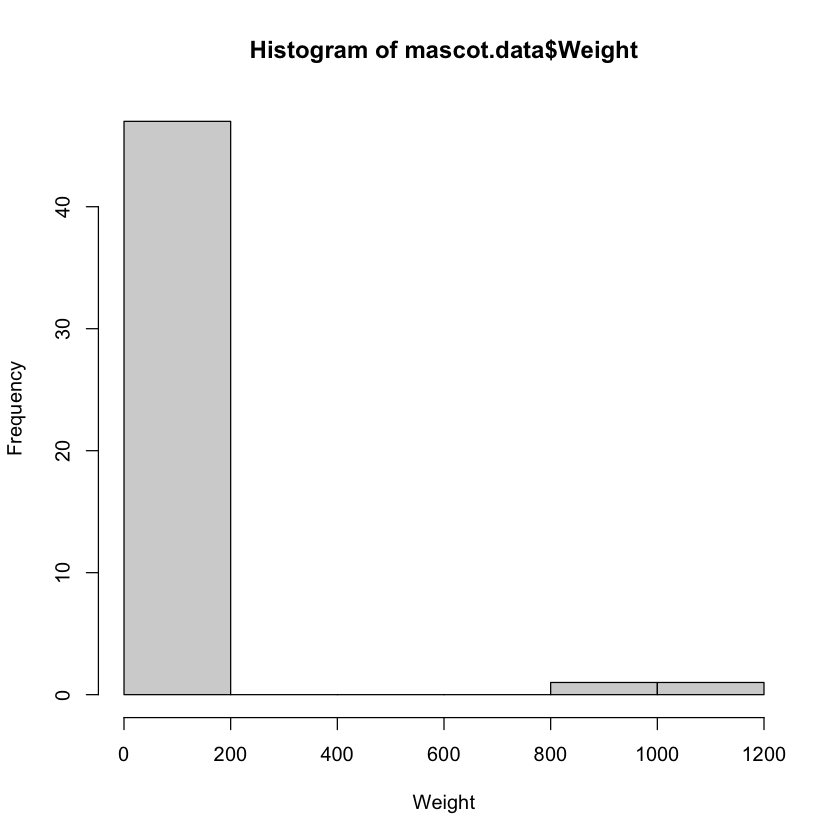

In [24]:
# make a histogram of Weight
hist(mascot.data$Weight,
    #  breaks = 50,
     xlab = "Weight",
     ylab = "Frequency")


What observations can we make from the histogram of `Weight`?

Possible observations:
1. Most of the values are < 200
2. There are two potential outliers > 800


Next steps:
We should look at a histogram for values < 200 and identify which rows are associated with the outliers.

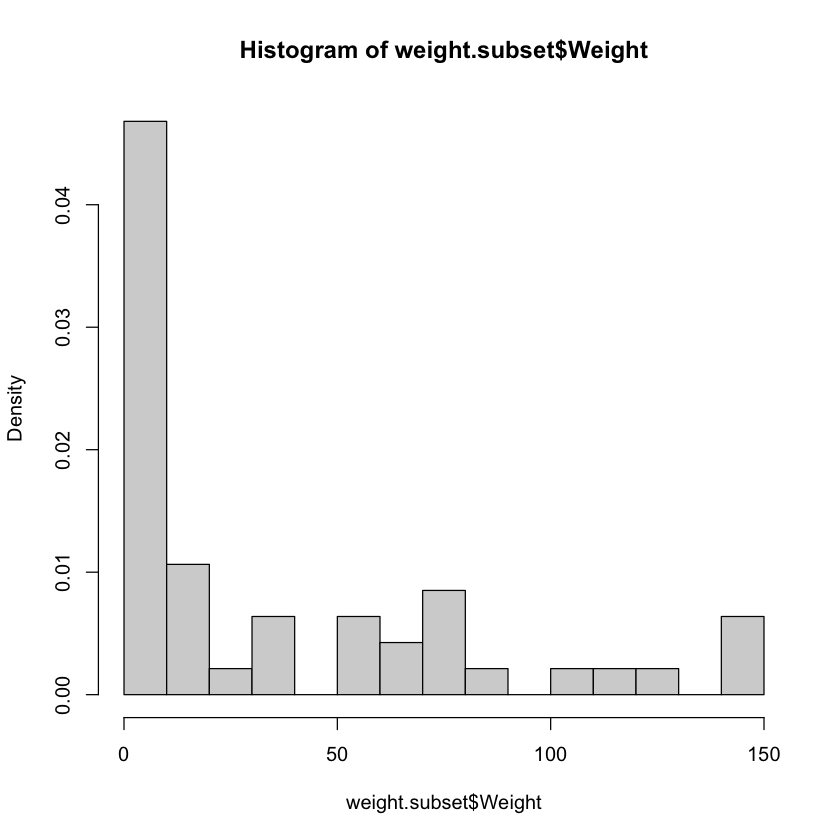

In [25]:
# Create histogram of Weight < 200
weight.subset <- mascot.data %>%
  filter(Weight < 200)

hist(weight.subset$Weight,
     breaks = seq(0, 150, by = 10),
     prob = TRUE)

In [26]:
# Identify Weight outliers show Name, Species, Breed and Weight
mascot.data[mascot.data$Weight > 200, c('Name', 'Species', 'Breed', 'Weight')]

,Name,Species,Breed,Weight
,<chr>,<chr>,<chr>,<dbl>
NA,NA,NA,NA,NA
31,Duke,Horse,Arabian,850.28
32,Peanut,Horse,Quarter Horse,1076.82


What observations can we make about the distribution of weights < 200 of these outliers?

Possible observations:
1. The largest proportion of animals have a weight under 10 lbs.
2. The outliers are not in error. We expect large weights in Horses.

We can use a boxplot to explore the distribution in height.

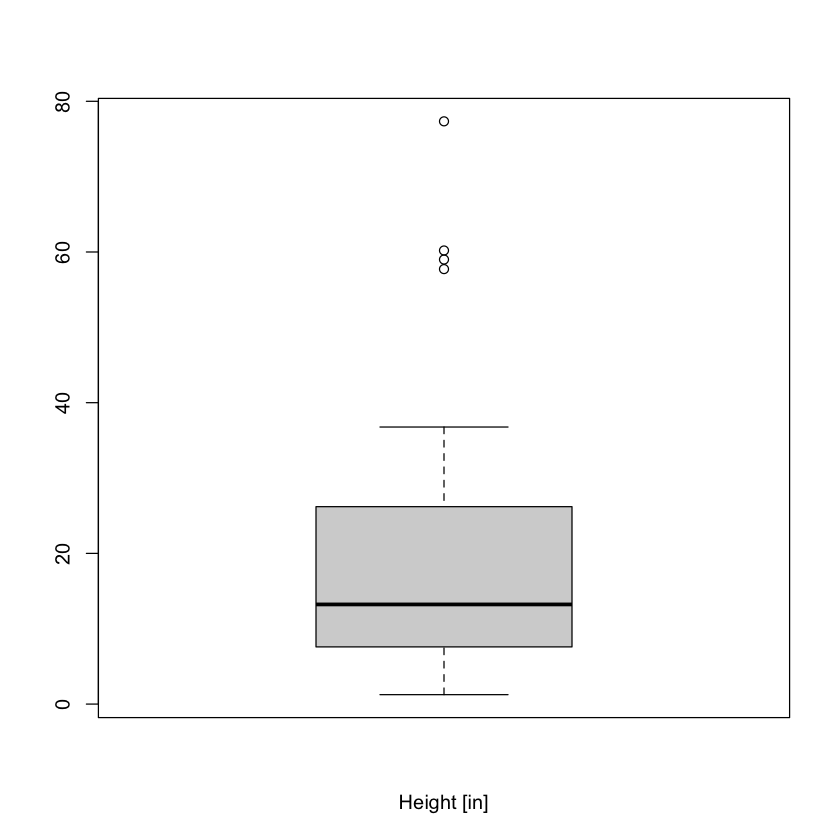

In [27]:
# Generate a boxplot of Height
boxplot(mascot.data$Height,
        xlab = 'Height [in]')

What observations can we make?

Possible observations:
1. The median height is around 12-13.
2. 50% of the values lie between ~ 5 and 25.
2. There are no outliers in the lower region 1.5*IQR.
3. There are 4 outliers in the upper 1.5*IQR region.

Using code provided above, generate the following:
1. a list of the height outliers visible in the boxplot
2. a histogram or boxplot of starting salary
3. a histogram or boxplot of age
Also, make some observations about the output for these three items.

In [28]:
# List of height outliers Show Name, Species, Breed and Height
mascot.data[mascot.data$Height > 40, c('Name', 'Species', 'Breed', 'Height')]

,Name,Species,Breed,Height
,<chr>,<chr>,<chr>,<dbl>
15,Banjo,Dog,Saint Bernard,77.34
30,Draco,Horse,Morgan,59.00
31,Duke,Horse,Arabian,57.73
32,Peanut,Horse,Quarter Horse,60.20


**TRY IT!**

Using code above, create a histogram and boxplot of `Starting.Salary` and `Age`. If there are outliers, extract them into a table.

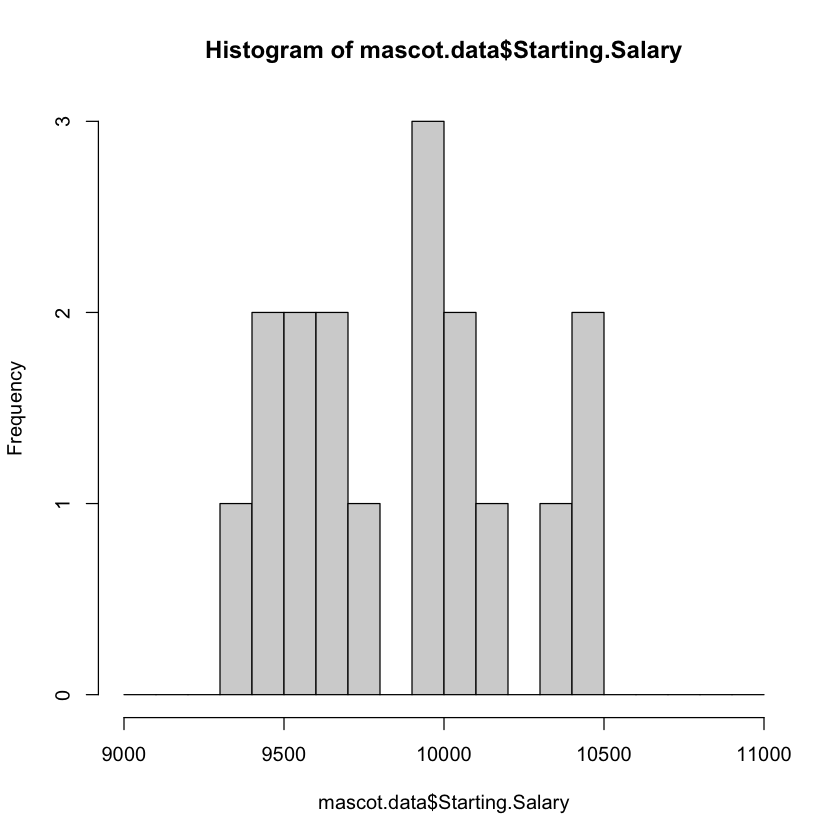

In [29]:
# Histogram of Salary
hist(mascot.data$Starting.Salary,
     breaks = seq(9000, 11000, by = 100))

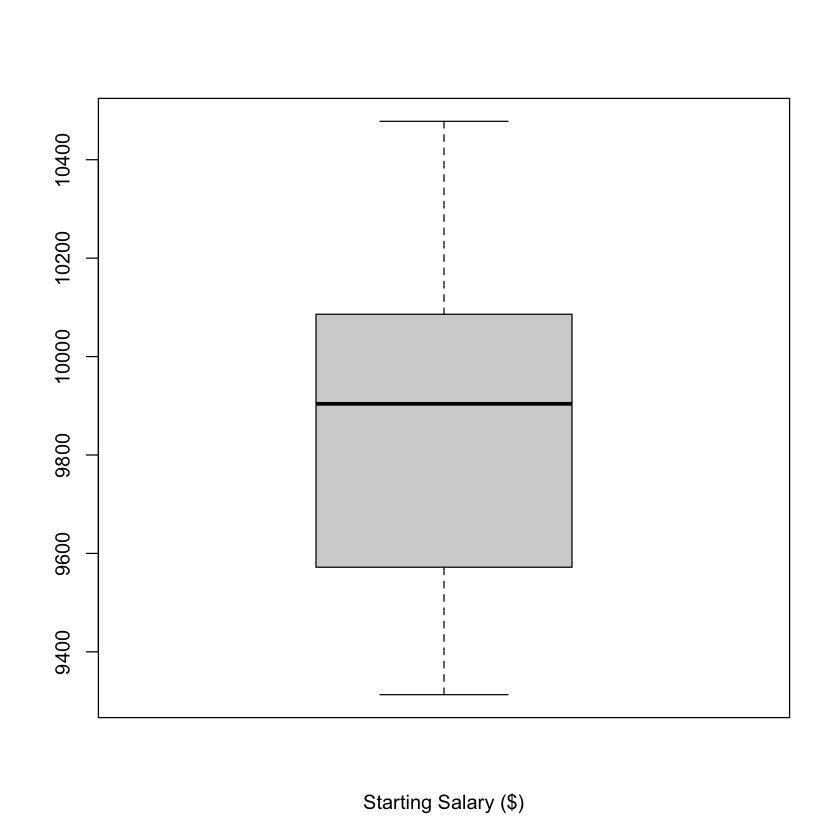

In [30]:
# Boxplot of starting salary
boxplot(mascot.data$Starting.Salary,
        xlab = "Starting Salary ($)")

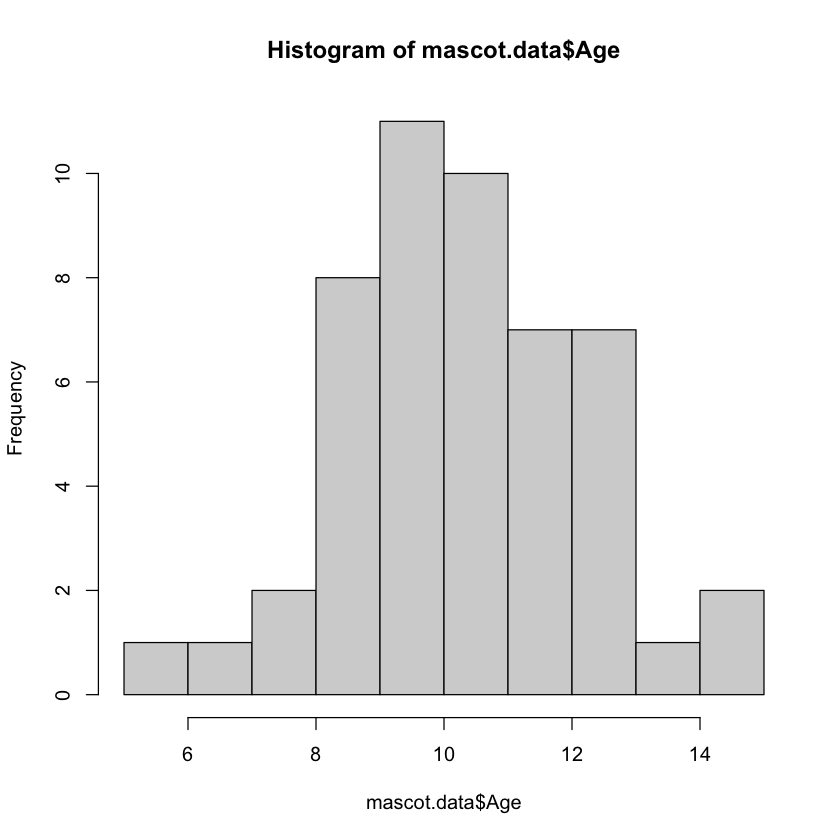

In [31]:
# histogram of age
hist(mascot.data$Age)

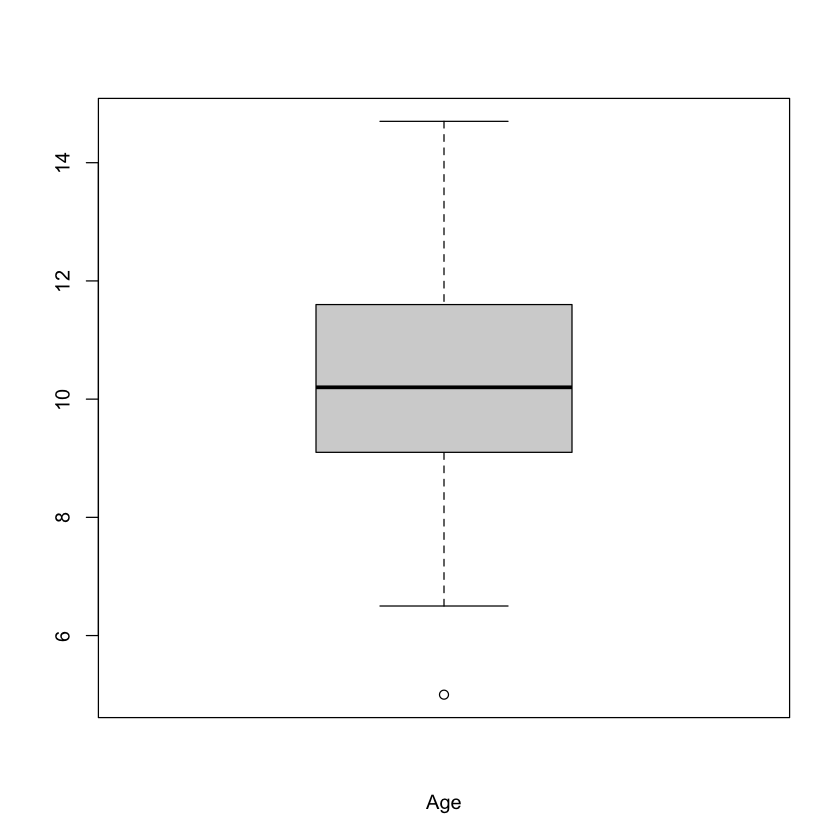

In [32]:
# Boxplot of Age
boxplot(mascot.data$Age,
        xlab = "Age")

In [33]:
# Extract Age outlier
mascot.data[mascot.data$Age < 6.5, c('Name', 'Species', 'Breed', 'Age')]

,Name,Species,Breed,Age
,<chr>,<chr>,<chr>,<dbl>
1,Wallace Whitfield Riddick,Human,,5


What observations can we make about the height outliers, and histogram and boxplot of starting salary and age? Age Outliers?

Possible observations:
1. The height outliers are probably not an error. We expect horses to be tall. It is likely that the value for Banjo, the St. Bernard is also probably appropriate.
2. No starting salaries in the range 9900-10000 or 10200-10300
3. The median starting salary is about 9900 and there is a slight left skew
4. 50% of the starting salaries are between 9600-10100
5. Starting salary shows no outliers.
6. Most mascots in the data are aged 9-11
7. Median age is about 10.5 years.
8. There is one outlier in the lower 1.5*IQR.

#### Categorical

We use barplots for univariate categorical data. The following columns in our data frame are categorical and in order of number of unique values:

<table>
<tr>
<td>

1. Post-Employment.Position
1. Termination.Reason
1. Fur.Color
1. Temperment
1. Nick Name
1. Species
1. Prior.Employer
1. Prior.Position
1. Breed
1. Name
</td>
<td>



</td>
</tr>
</table>

We'll start with columns that don't have a lot of unique values.

We won't bother making plots of
`Nick.Name` or `Name` since they are labels for the data.

We use the [`barplot()`](https://www.rdocumentation.org/packages/graphics/versions/3.6.2/topics/barplot) function to generate a barplot.

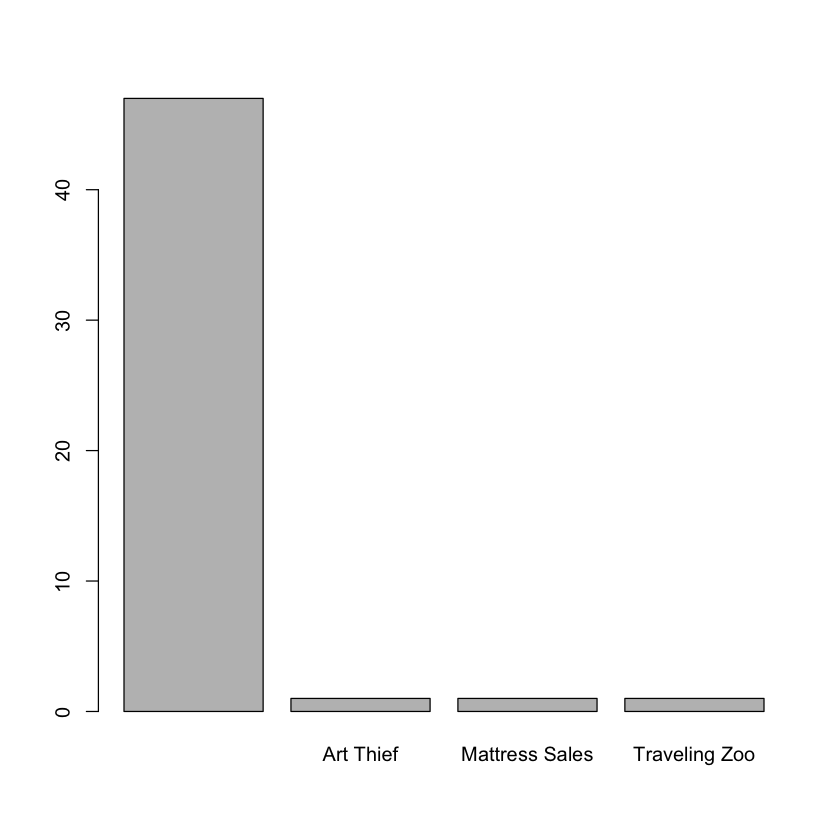

In [34]:
# Create a barplot of Post.Employment.Position
barplot(table(mascot.data$Post.Employment.Position))

We can tweak base R plots by setting graphical parameters using the [`par()`](https://www.rdocumentation.org/packages/graphics/versions/3.6.2/topics/par) function.

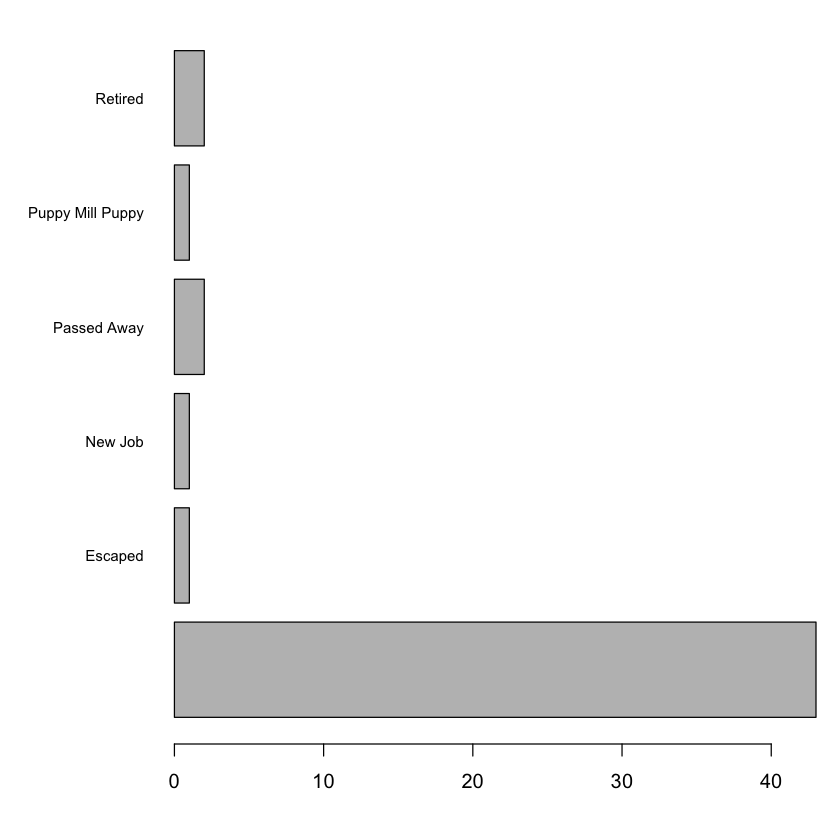

In [35]:
# Create a barplot of Termination.Reason
# save default par() values
opar <- par()

# change borders on plot by modifying
# the mar parameter
par(mar = c(4,7,1,1))
# mar = c(bottom, left, top, right)
# default par(mar = c(5.1, 4.1, 4.1, 2.1))
# unit in lines of text

# Generate barplot
barplot(table(mascot.data$Termination.Reason),
        horiz = TRUE,
        las = 1,
        cex.names = .75)

# reset par()
suppressWarnings(par(opar))

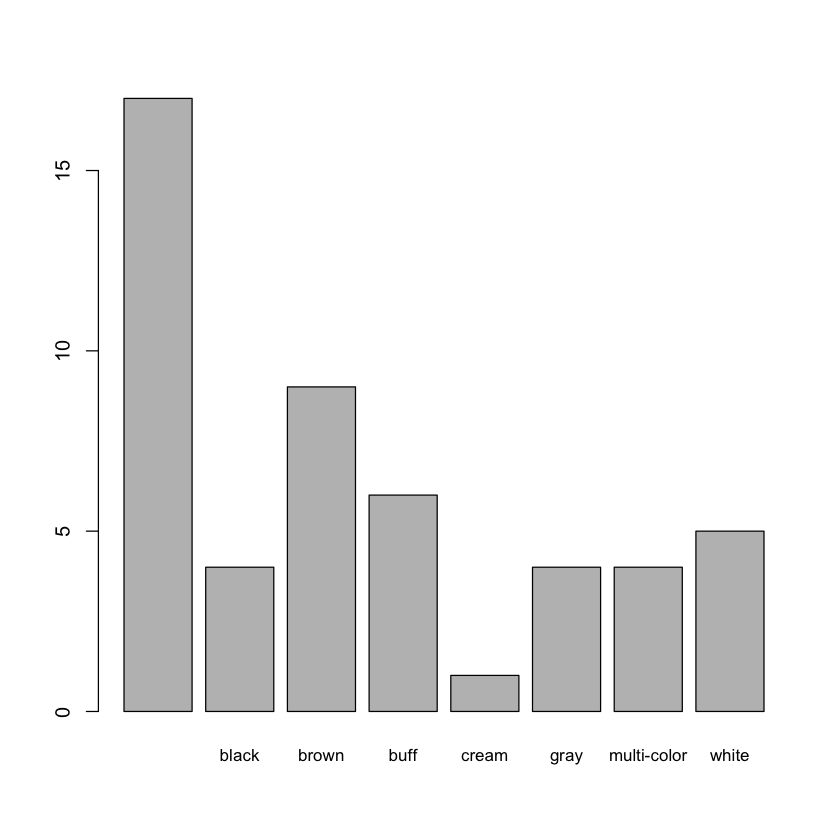

In [36]:
barplot(table(mascot.data$Fur.Color),
              cex.names = .85)

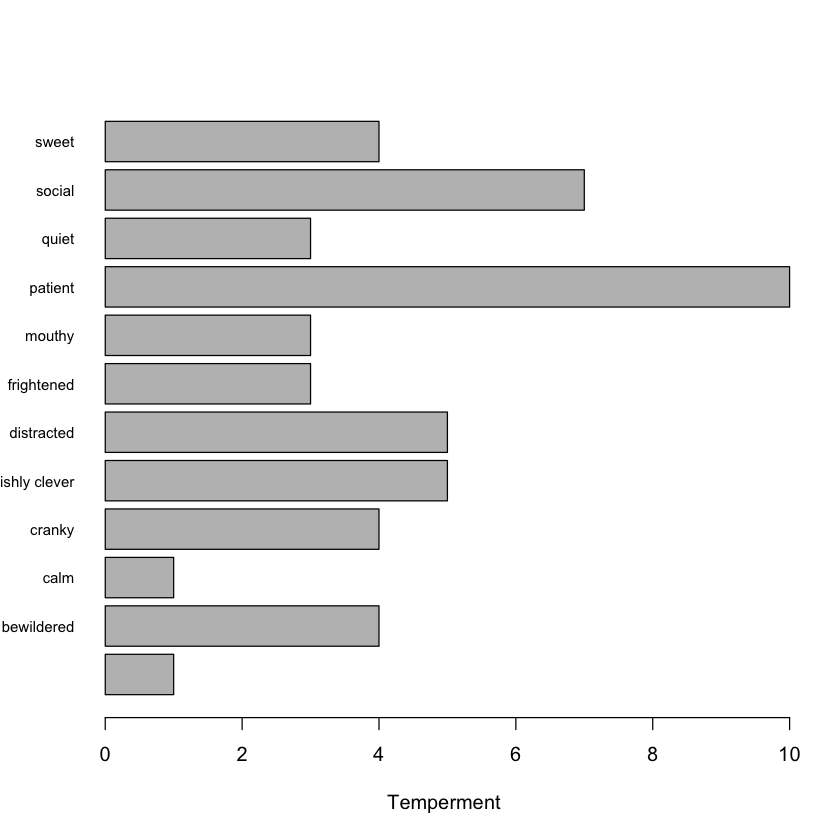

In [37]:
# Create barplot of Temperment
barplot(table(mascot.data$Temperment),
              xlab = "Temperment",
              horiz = TRUE,
              las = 1,
              cex.names = .75)

An improvement to the chart of `Temperment` would be to sort from largest to smallest values. We can use the [`dplyr`](https://r4ds.hadley.nz/data-transform.html) package in `tidyverse` to accomplish this.

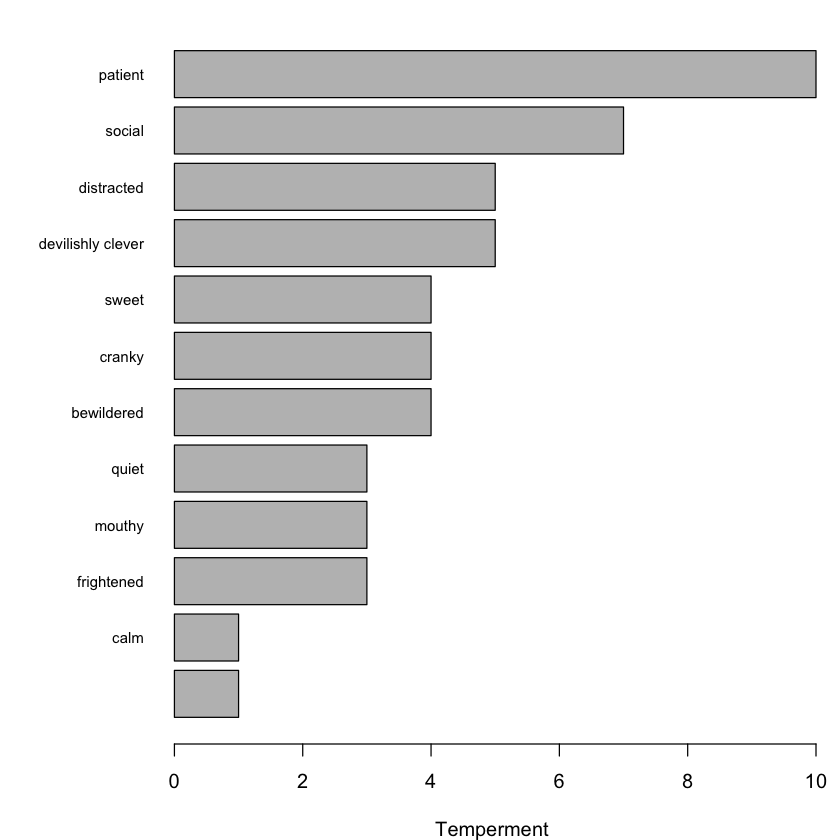

In [38]:
# Group data by breed and create counts
val.counts <- mascot.data %>%
  group_by(Temperment) %>%
  count() %>%
  arrange(n)

# Save default par() values
opar <- par()
# Set par()
par(mar = c(4,7,1,1))

barplot(val.counts$n,
              names.arg = val.counts$Temperment,
              xlab="Temperment",
              horiz=TRUE,
              las = 1,
              cex.names = .75)
suppressWarnings(par(opar))

**TRY IT!**

Using the code used to generated the sorted plot for counts of `Temperment`, create a similar visualization for `Species` and `Breed`.

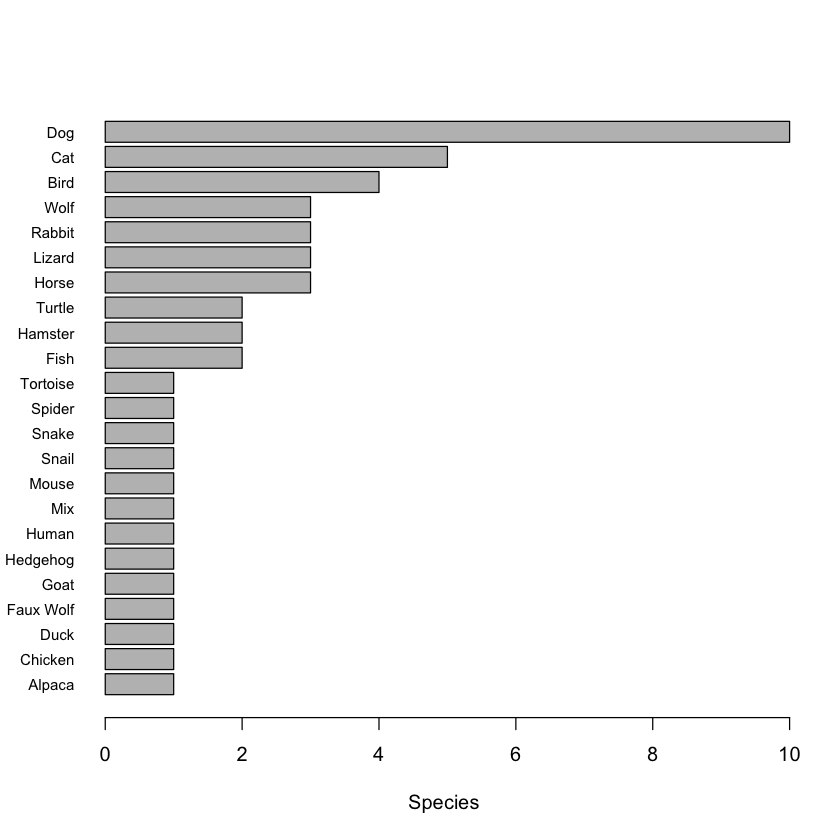

In [39]:
# grab counts of Species and sort data
# to get largest values on top need ascending sort
# arrange defaults to ascending sort
val.counts <- mascot.data %>%
  group_by(Species) %>%
  count() %>%
  arrange(n)

barplot(val.counts$n,
        names.arg = val.counts$Species,
              xlab = "Species",
              horiz = TRUE,
              las = 1,
              cex.names = .75) # makes font size for names smaller

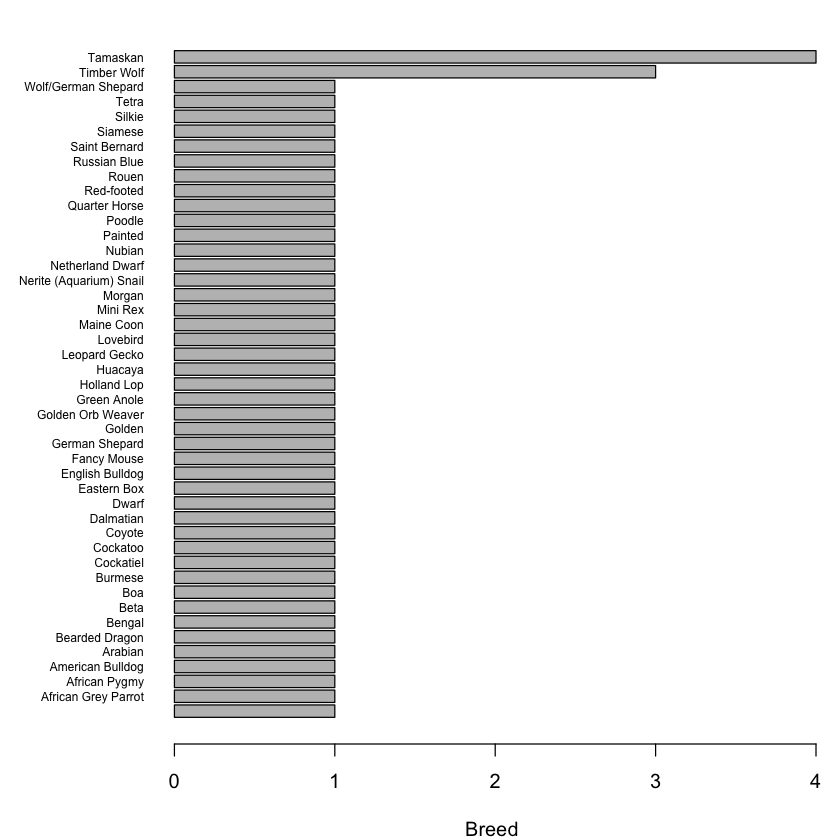

In [40]:
# Barplot of Breed

# Group data by breed and create counts
val.counts <- mascot.data %>%
  group_by(Breed) %>%
  count() %>%
  arrange(n)

# save default par() values
opar <- par()

# change borders on plot by modifying
# the mar parameter
par(mar = c(4,7,1,1))
# mar = c(bottom, left, top, right)
# default par(mar = c(5.1, 4.1, 4.1, 2.1))
# unit in lines of text

barplot(val.counts$n,
        names.arg = val.counts$Breed,
              xlab = "Breed",
              horiz = TRUE,
              las = 1,
              cex.names = .6)
suppressWarnings(par(opar))

#### Factors

We defined the following factors:
- Offer.Sent.Factor
- Biter.Factor
- Hired.Factor

We visualize factors like other categorical columns.

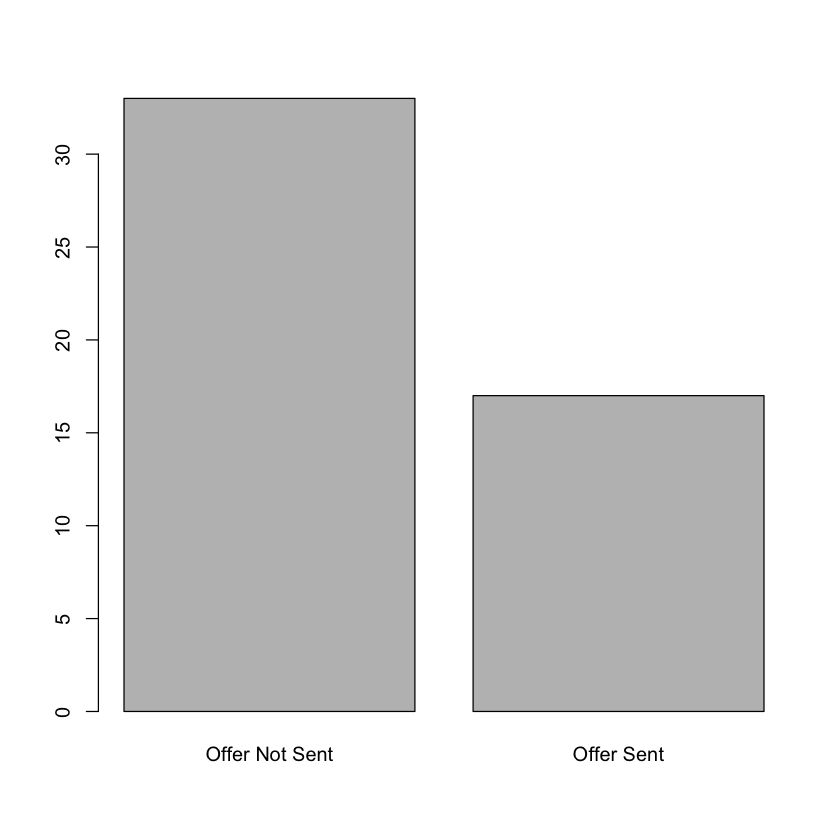

In [41]:
# Create barplot of Offer.Sent
barplot(table(mascot.data$Offer.Sent.Factor))

**TRY IT!**

Using code above, make a `barplot` of `Biter.Factor` and `Hired.Factor`

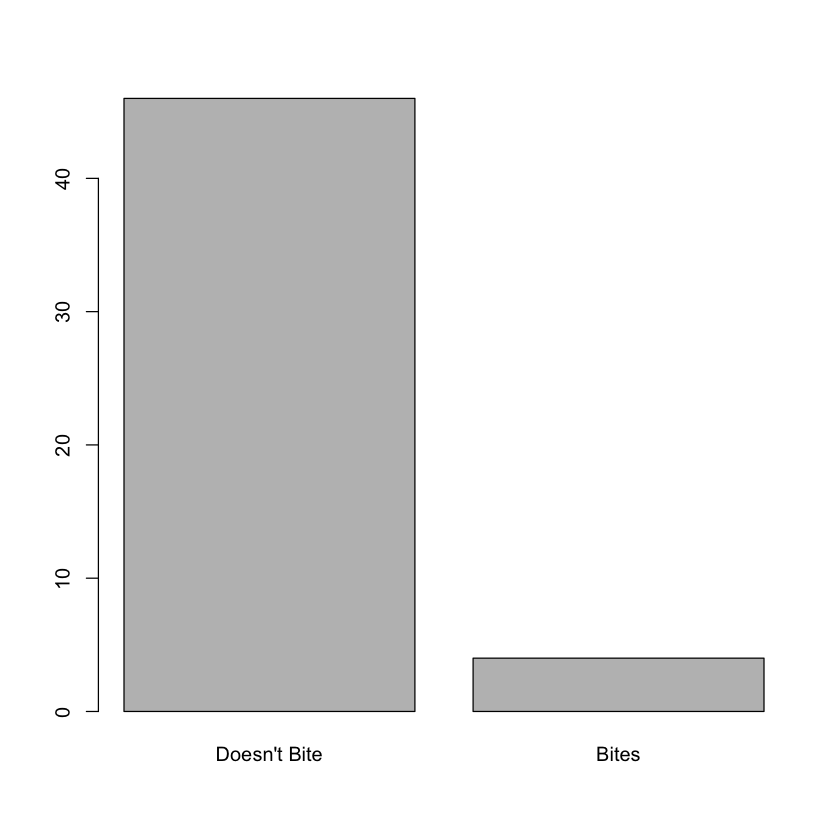

In [42]:
# Create barplot of Biter
barplot(table(mascot.data$Biter.Factor))

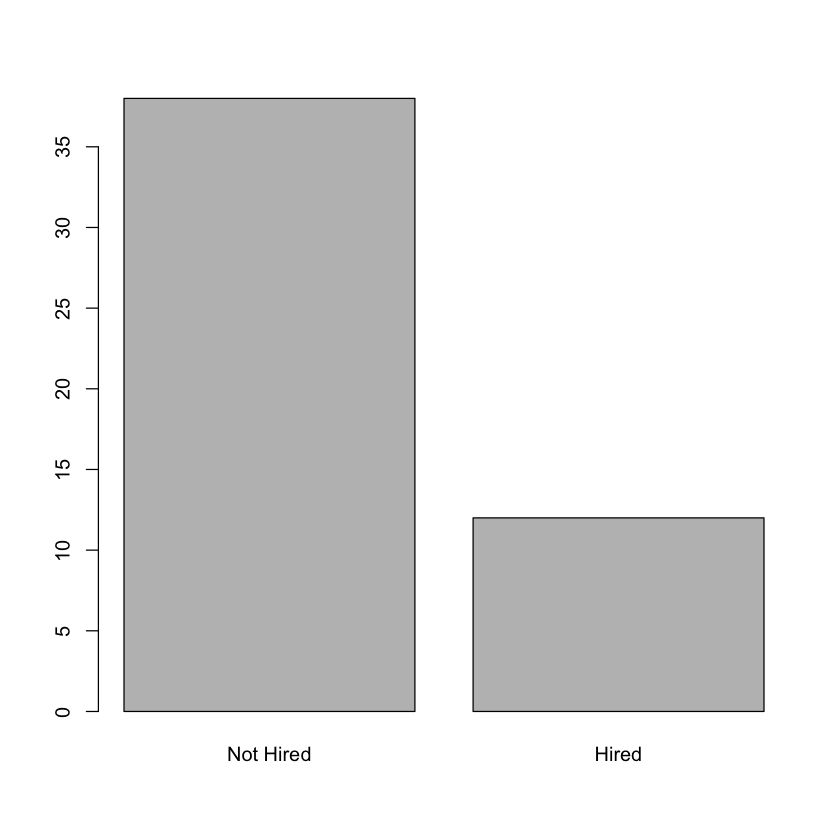

In [43]:
# Create barplot of Hired
barplot(table(mascot.data$Hired.Factor))

#### Dates
Dates can be visualized as categorical variables by grouping them. Grouping over day, month, year or a combination may be informative.

Dates in our data include:
- Interview.Date
- Hire.Date
- Termination.Date

Hire.Date and Termination.Date are grouped in the data in the fields Hire.Year and Termination.Year

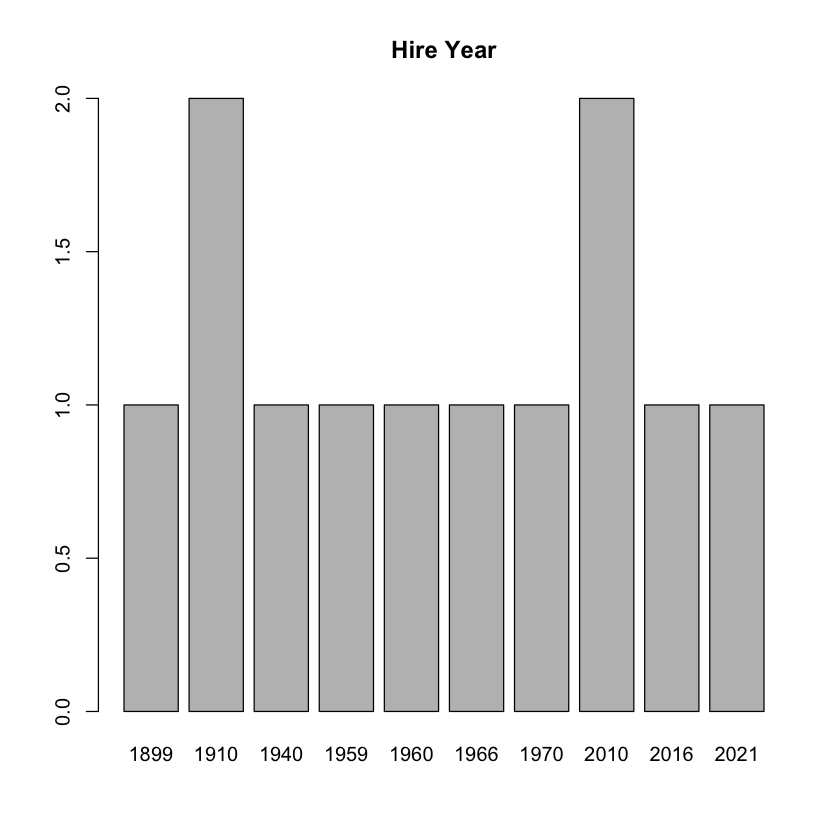

In [44]:
# Create a barplot of Hire.Year
barplot(table(mascot.data$Hire.Year),
        main="Hire Year")

Use the code above to generate a plot of Termination.Year.

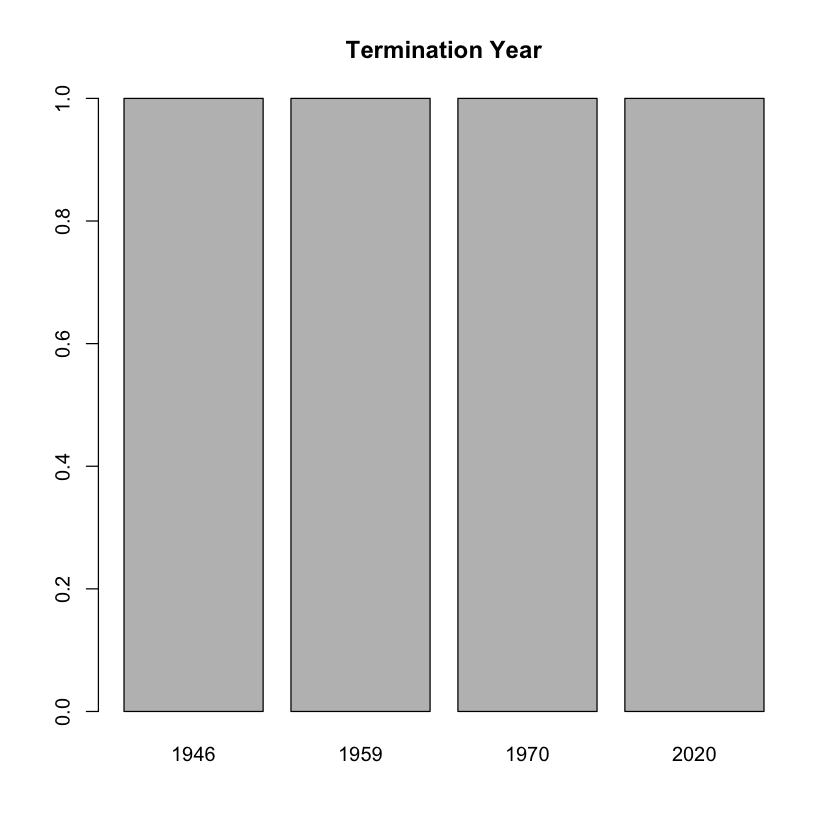

In [45]:
# Create barplot of Termination.Year
barplot(table(mascot.data$Termination.Year),
        main="Termination Year")

To create a barplot of Interview.Date by year, we need to use the `lubridate` function `year()`.

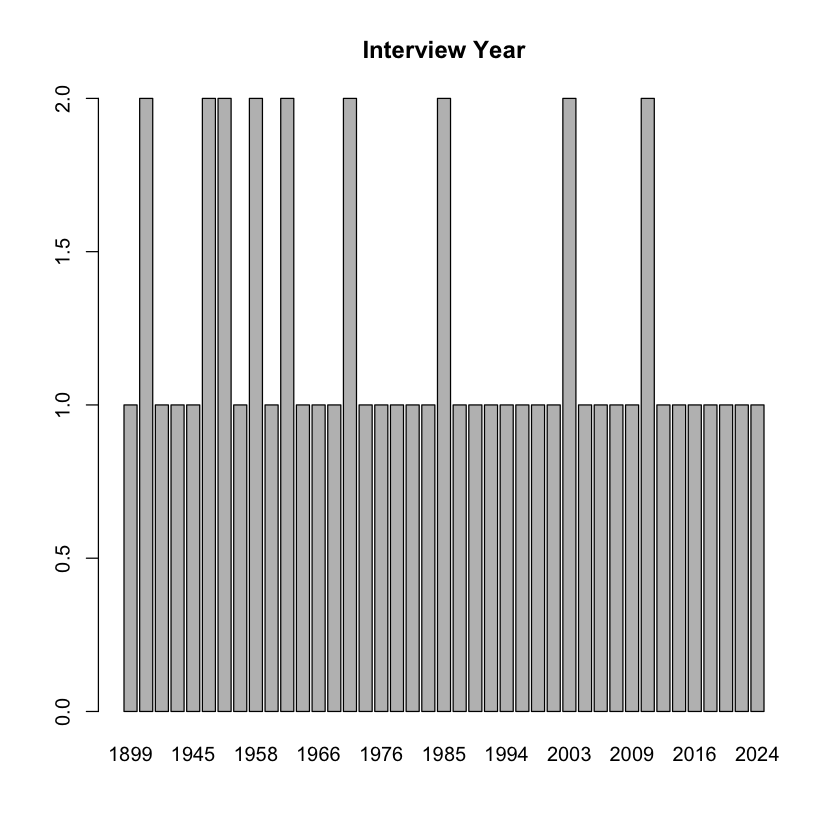

In [46]:
# Create a barplot of Interview.Date grouped by Year
barplot(table(year(mascot.data$Interview.Date)),
        main="Interview Year")

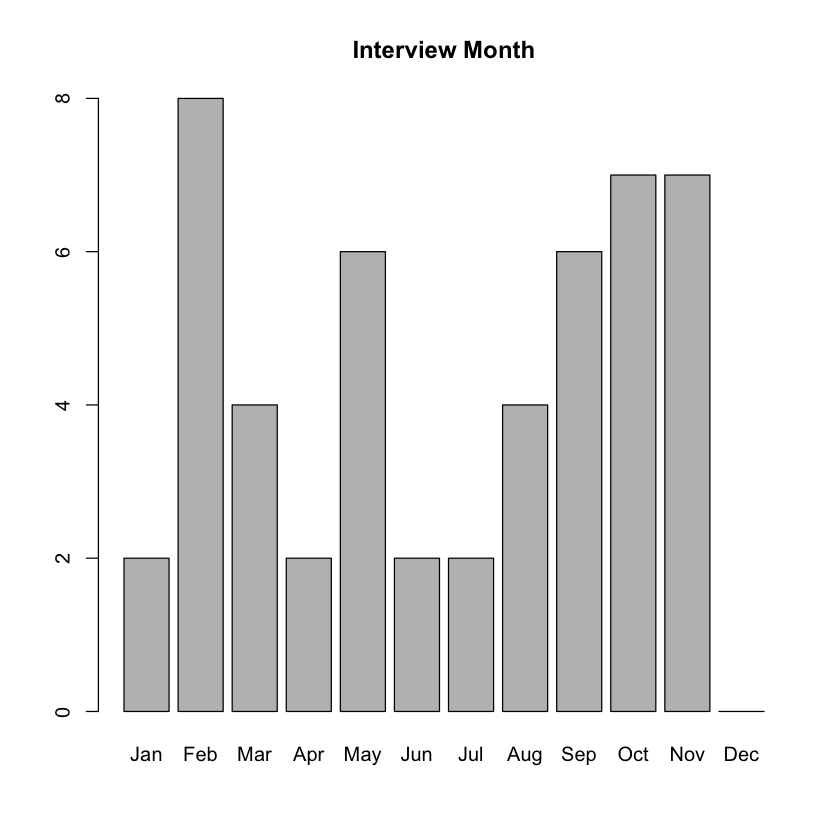

In [47]:
# Create a barplot of Interview.Date grouped by Month
barplot(table(month(mascot.data$Interview.Date, label = TRUE)),
        main="Interview Month")

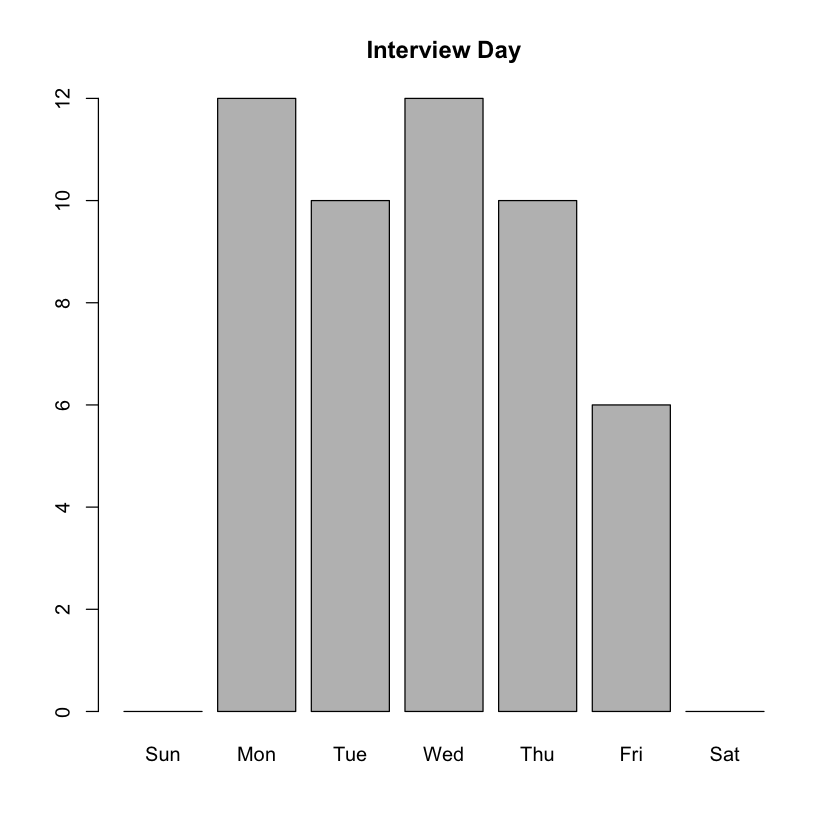

In [48]:
# Create a barplot of Interview.Date grouped by Month
barplot(table(wday(mascot.data$Interview.Date, label = TRUE)),
        main="Interview Day")

### Bivariate Plots

#### [Pair Plots](https://intro2r.com/simple-base-r-plots.html#pairs-plots) (2 Numeric Columns)

A pair plot generates a scatter plot between each numeric column in the data passed to `pairs()`. The three columns that we converted to factors, `Hired`, `Offer.Sent`, and `Biter` are still in our data in numeric form, so they are included in our pair plot.

[1] "Hire.Year"        "Termination.Year" "Age"              "Height"          
[5] "Weight"           "Offer.Sent"       "Starting.Salary"  "Biter"           
[9] "Hired"

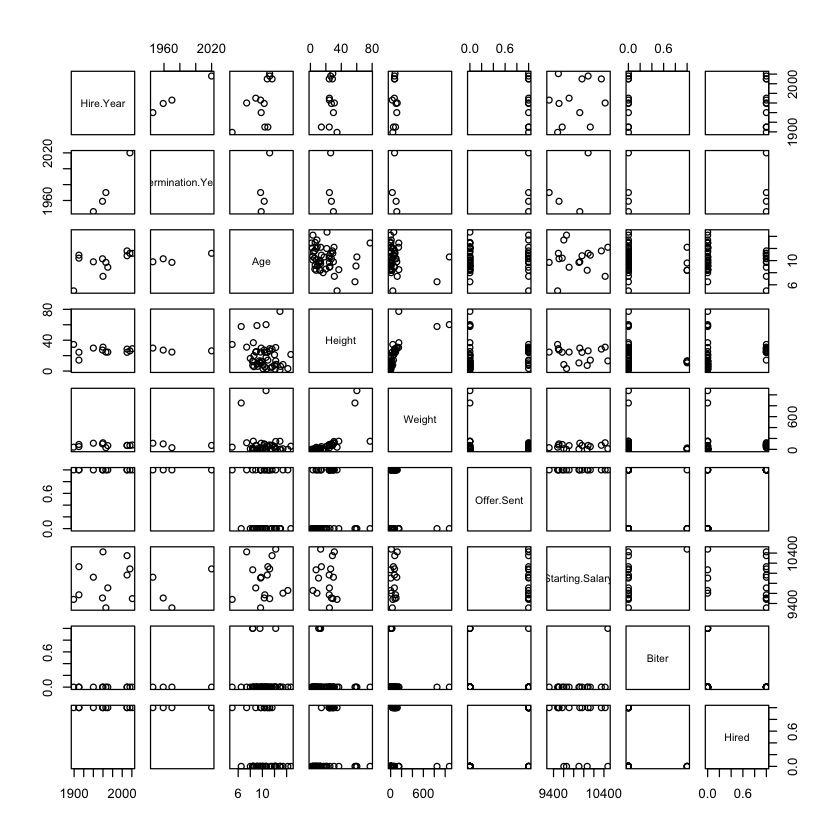

In [49]:
num.cols <- mascot.data %>%
  select(where(is.numeric)) # a smaller df with character columns
names(num.cols)

pairs(num.cols)


In a large dataset, we might focus on a subset of fields that are of interest. Using the code above, create a subset of data using the columns `Hired`, `Starting.Salary`, `Age`, `Height` and `Weight` and create a pairs plot from this subset. Hint: you can pass the names of the columns you want to keep to the `select()` function.

[1] "Hired"           "Starting.Salary" "Age"             "Height"         
[5] "Weight"

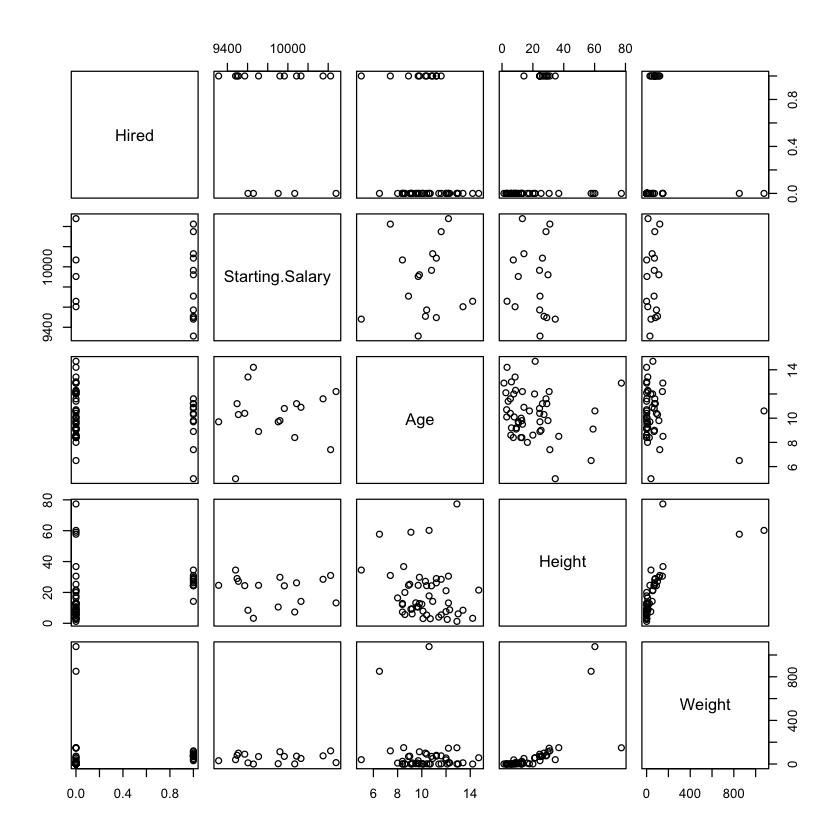

In [50]:
# Select the subset of columns for the pair plot
num.cols <- mascot.data %>%
  select('Hired', 'Starting.Salary', 'Age', 'Height', 'Weight') # a smaller df with character columns
names(num.cols)

# Generate the pair plot
pairs(num.cols)


#### [Scatter Plots](https://intro2r.com/simple-base-r-plots.html#scatterplot) (2 Numeric Columns)

Once we investigate pair plots, we can use scatter plots to focus on continuous values of interest.

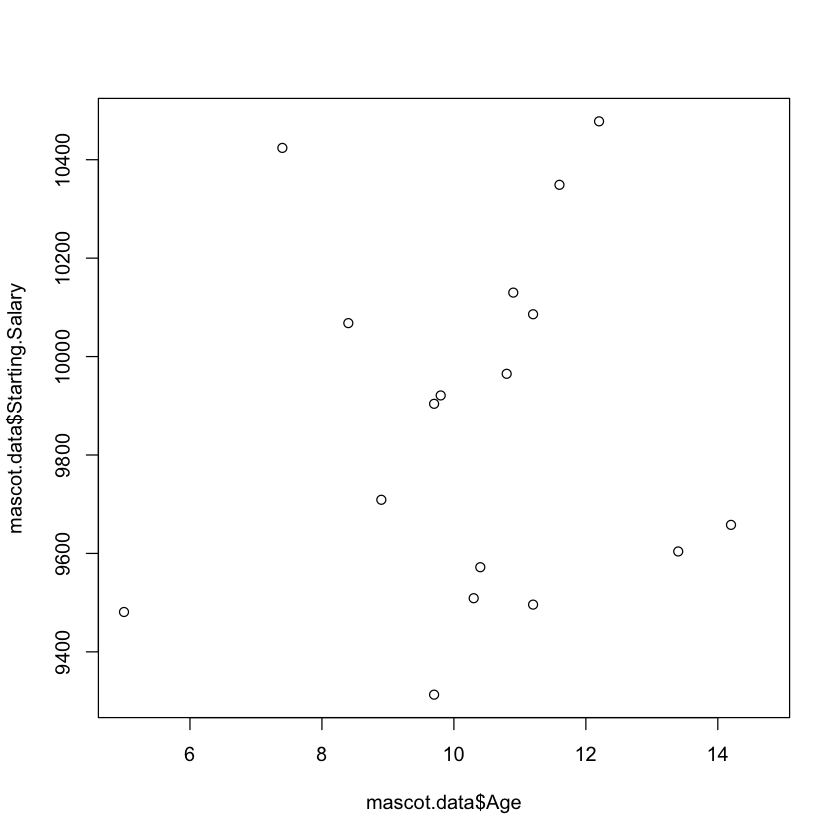

In [51]:
plot(mascot.data$Age,mascot.data$Starting.Salary)


#### [Barcharts](https://www.datacamp.com/doc/r/bar) (1 Categorical 1 Numeric)

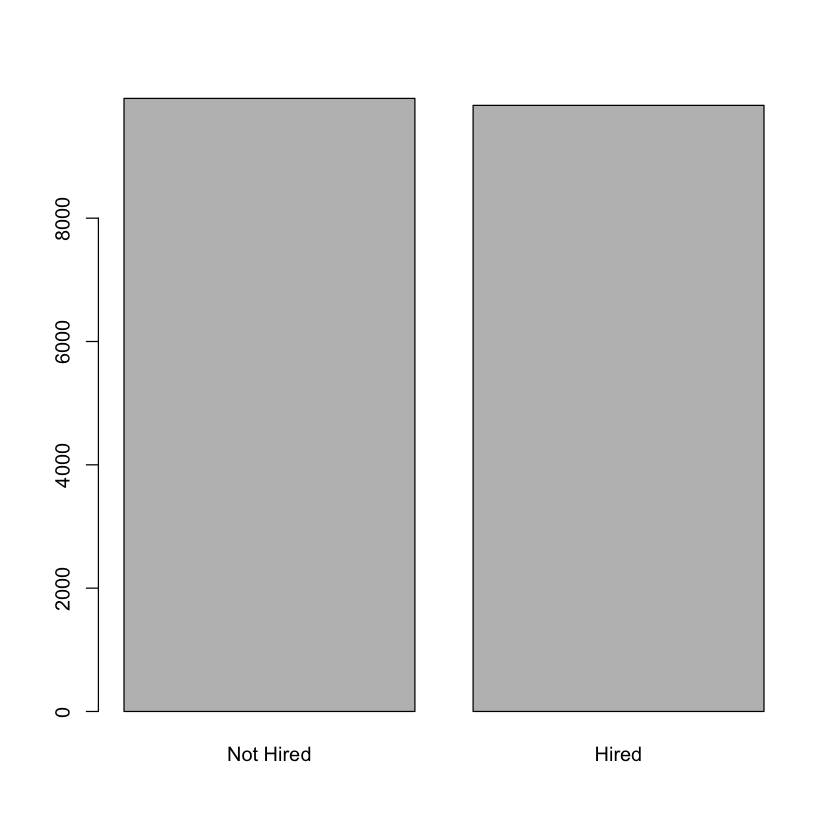

In [52]:
data <- mascot.data %>%
  group_by(Hired.Factor) %>%
  summarise(Salary = mean(Starting.Salary, na.rm = TRUE))

barplot(data$Salary,
        names.arg = data$Hired.Factor
        )


#### [Grouped Barcharts](https://www.datacamp.com/doc/r/bar) (2 Categorical 1 Numeric)

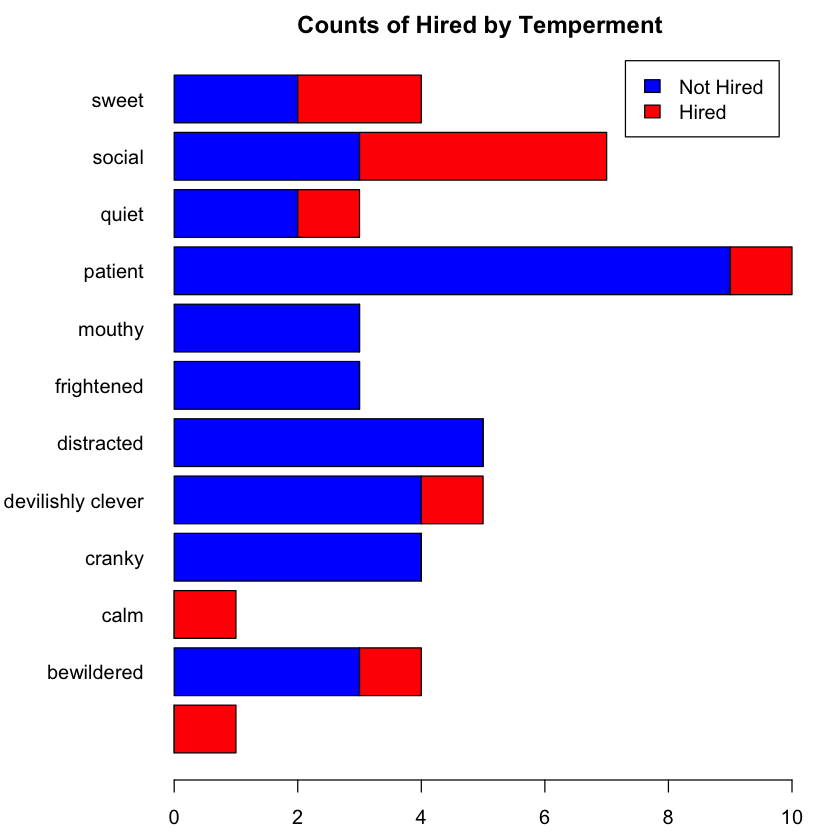

In [53]:
counts <- table(mascot.data$Hired.Factor, mascot.data$Temperment)

opar <- par()
par(mar = c(2.5, 7, 2, 2))
barplot(counts,
        main = "Counts of Hired by Temperment",
        xlab="Temperment", col=c("blue","red"),
        legend = rownames(counts),
        horiz = TRUE,
        las = 1,
        cex.lab = .75)
suppressWarnings(par(opar))

### Multivariate Plots

#### [Scatter Plots](https://www.sthda.com/english/wiki/scatter-plots-r-base-graphs)

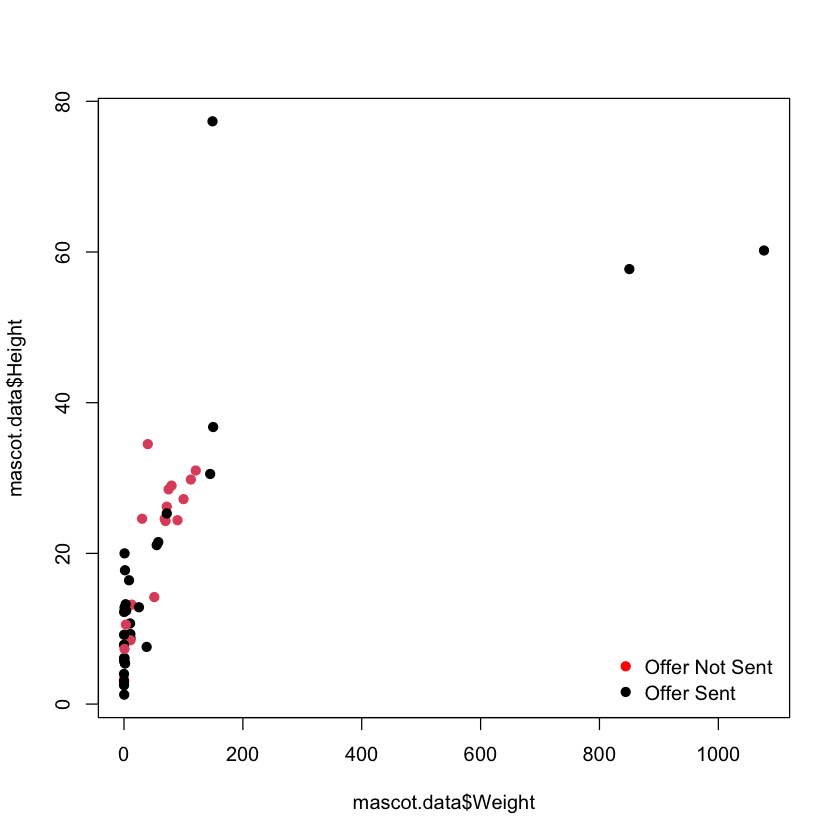

In [54]:
# Using a factor
plot(mascot.data$Weight, mascot.data$Height,
     pch = 19,
     col = mascot.data$Offer.Sent.Factor)
legend('bottomright',
       col = c('red','black'),
       pch = 19,
       legend = levels(mascot.data$Offer.Sent.Factor),
       bty = 'n')

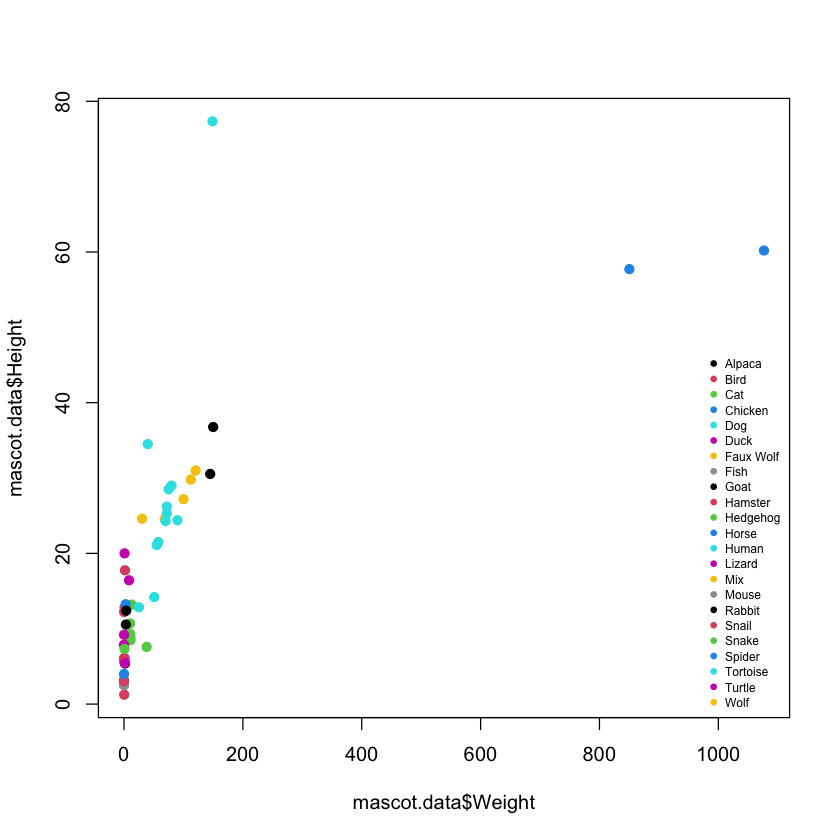

In [55]:
# Using a categorical which is not a factor
plot(mascot.data$Weight, mascot.data$Height,
     pch = 19,
     col = as.factor(mascot.data$Species))
legend('bottomright',
       legend = levels(as.factor(mascot.data$Species)),
       col = as.factor(levels(as.factor(mascot.data$Species))),
       cex = .6,
       bty = 'n',
       pch = 19)

#### Barplots

We can generate barplots for multivariate data by using grouped or stacked bar charts.

In [56]:
# generate data by grouping it by two categorical variables
# and summarising a continuous variable
data <- mascot.data %>%
  group_by(Hired.Factor, Temperment) %>%
  summarise(Salary = mean(Starting.Salary, na.rm = TRUE)) %>%
  drop_na() %>%
  filter(Temperment != "")
data


`summarise()` has grouped output by 'Hired.Factor'. You can override using the
`.groups` argument.


Hired.Factor,Temperment,Salary
<fct>,<chr>,<dbl>
Not Hired,cranky,10478.00
Not Hired,distracted,9863.00
Not Hired,patient,9604.00
Not Hired,social,9904.00
Hired,bewildered,9921.00
Hired,calm,9709.00
Hired,devilishly clever,10424.00
Hired,patient,9481.00
Hired,quiet,9509.00


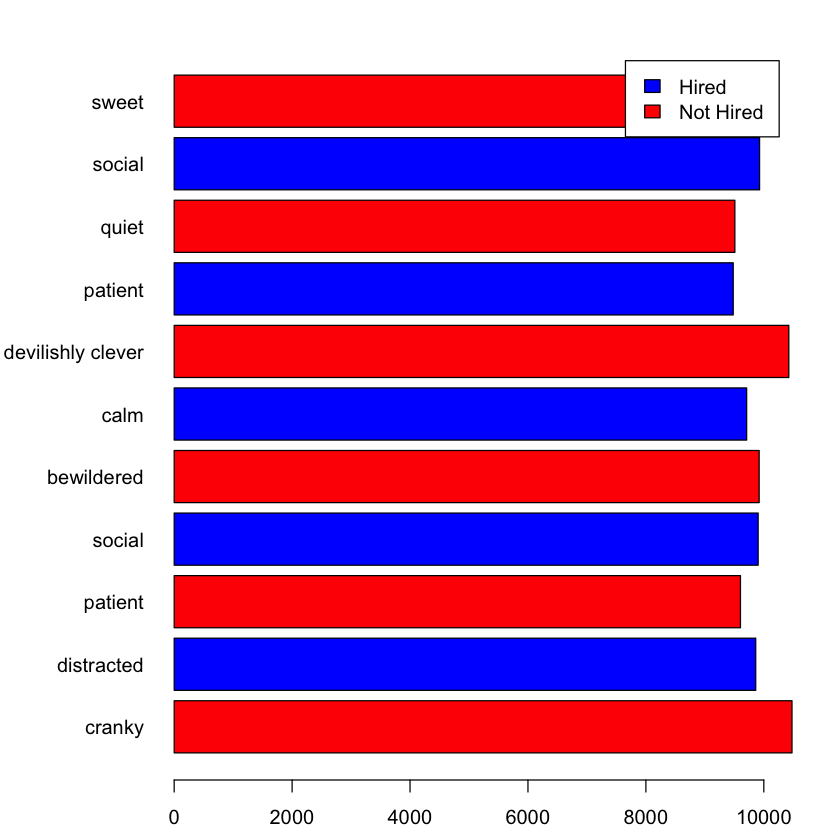

In [57]:
# Generate plot from data
opar <- par()
par(mar = c(2.5, 7, 2, 2))
barplot(data$Salary,
        names.arg = as.factor(data$Temperment),
        legend = unique(data$Hired.Factor),
        col = c("red","blue"),
        horiz = TRUE,
        las = 1)
suppressWarnings(par(opar))

#### [Coplots](https://intro2r.com/simple-base-r-plots.html#coplots)

In [58]:
coplot.data <- mascot.data %>%
  drop_na(Weight, Height, Starting.Salary) %>%
  select(Weight,Height,Starting.Salary)
nrow(coplot.data)
summary(coplot.data)

[1] 17

     Weight             Height      Starting.Salary
 Min.   :  0.0003   Min.   : 3.25   Min.   : 9313  
 1st Qu.: 12.9500   1st Qu.:13.20   1st Qu.: 9572  
 Median : 68.5000   Median :24.60   Median : 9904  
 Mean   : 55.1935   Mean   :21.24   Mean   : 9863  
 3rd Qu.: 80.0000   3rd Qu.:28.50   3rd Qu.:10086  
 Max.   :120.7300   Max.   :34.50   Max.   :10478  

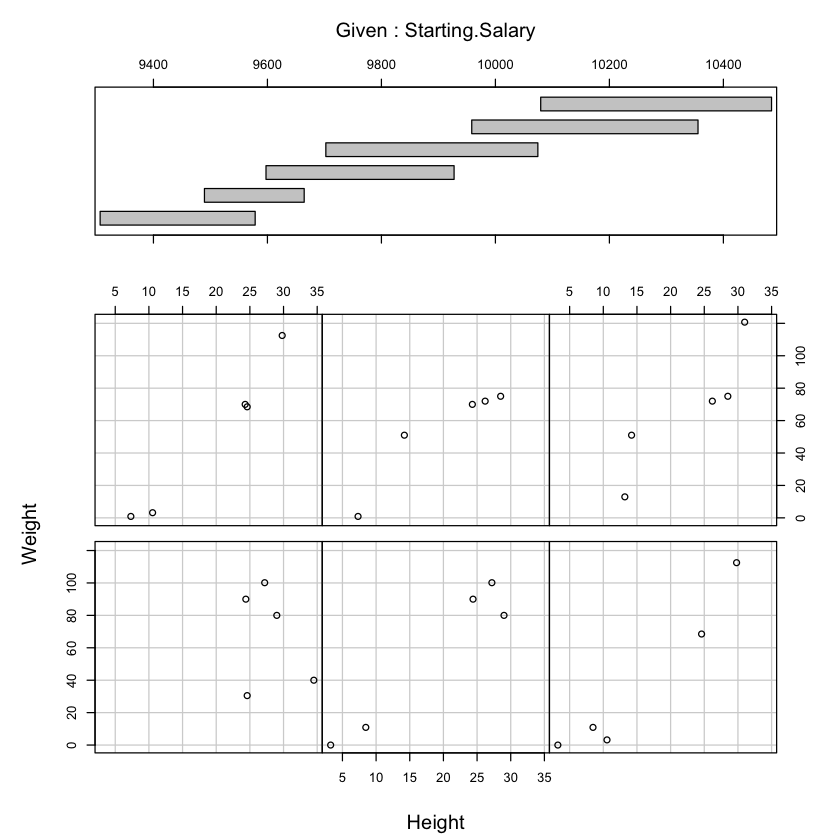

In [59]:
coplot(Weight ~ Height | Starting.Salary, data = coplot.data)


       [,1]    [,2]
[1,] 9306.5  9664.5
[2,] 9597.5 10074.5
[3,] 9958.5 10484.5


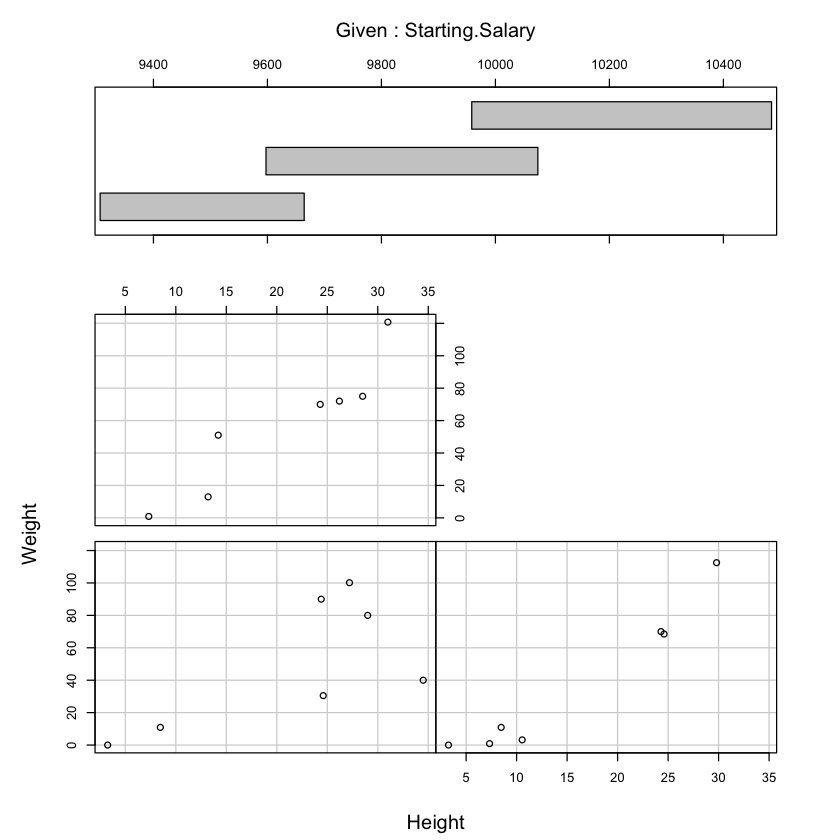

In [60]:
given.salary <- co.intervals(coplot.data$Starting.Salary,
                              number=3, overlap=.33)
print(given.salary)
coplot(Weight ~ Height | Starting.Salary, data = coplot.data,
       given.values = given.salary)

## Next Steps

We have explored the data quite a bit. Next steps would be to identify one or two relationships to explore further. This may involve subsetting the data further or using simple models like linear (continuous, fairly normal response) or logistic regression (binary/boolean response).

What relationships or trends do you think might be interesting?

Potential relationships:

- Breed or Species and Hired.Factor
- Age or Starting.Salary and Hired.Factor or Offer.Sent



Based on the data, what job do you think Barbara has at NC State?

**TRY IT ON YOUR OWN!**

Using the code above try exploring another dataset.



In [61]:
# Another synthetic dataset
celeb.url <- "https://raw.githubusercontent.com/NCSU-Libraries/eda-with-r/refs/heads/main/data/NCSU%20Celebrity%20Graduates_v1.csv"


## Links to additional resources

### R

[R for Data Science](https://r4ds.hadley.nz/)

[Introduction to R](https://intro2r.com/)

### Base R Plots
[Intro2R](https://intro2r.com/graphics_base_r.html)

[STHDA](https://www.sthda.com/english/wiki/r-base-graphs)

